# AvianNet V1: Baseline CNN Model
**Objective:** Evaluate performance of custom 3-Layer CNN on classifying 5 species of North American birds using Mel-Spectrograms.

**Data Notes:** 
* Dataset is filtered using RMS energy to remove silent audio chunks (those lacking bird calls to predict off of).
* Moderate class imbalance was addressed using inverse frequency weighting in CrossEntropyLoss.
* Split was applied by unique recording ID to prevent data leakage across time-chunks.

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from pathlib import Path

from src.model import AvianNetModelV1
from src.dataset import get_dataloaders
from src.config_loader import load_config

In [ ]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = AvianNetModelV1(input_shape=3, hidden_units=32, output_shape=5).to(device)

model_path = Path.cwd() / 'models' / 'avian_net_V1.pth'
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("Model weights loaded")

_, test_dataloader = get_dataloaders()
all_preds = []
all_true_labels = []
print("Running inference on the test dataset.")

with torch.inference_mode():
    for X_test, y_test in test_dataloader:
        X_test = X_test.to(device)
    
        
        
        # Convert logits to predicted class indices (0 through 4)
        logits = model(X_test)
        preds = logits.argmax(dim=1).cpu().numpy()
        true_labels = y_test.cpu().numpy()
        
        # Store for the confusion matrix
        all_preds.extend(preds)
        all_true_labels.extend(true_labels)

print(f"Inference complete. Processed {len(all_preds)} audio chunks.")

Model weights loaded
Running inference on the test dataset.
Inference complete. Processed 559 audio chunks.


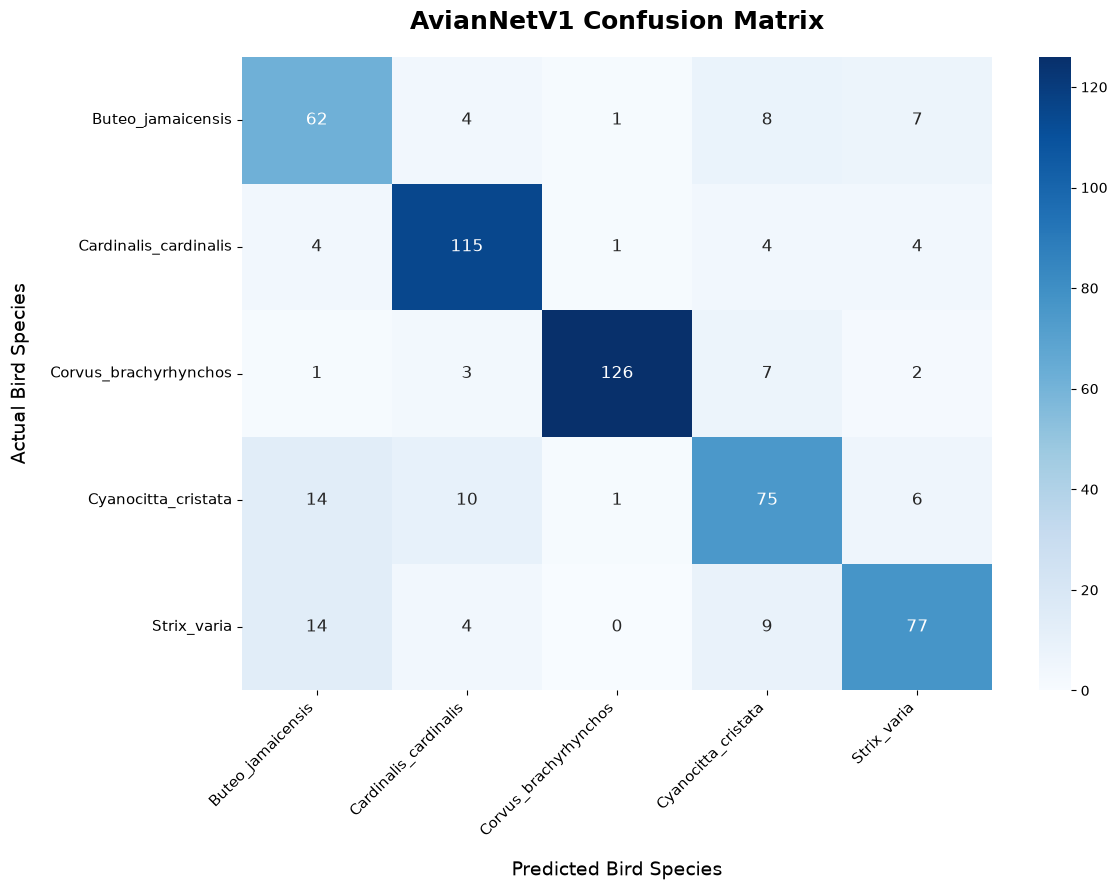

In [8]:
# Create the confusion matrix
cm = confusion_matrix(all_true_labels, all_preds)
dataset_dict = test_dataloader.dataset.species_to_idx_dict
bird_classes = [name for name, index in sorted(dataset_dict.items(), key=lambda x: x[1])]

# Matrix Plotting
plt.figure(figsize=(12, 9))
sns.heatmap(cm, 
            annot=True,       
            fmt='d',     
            cmap='Blues',
            xticklabels=bird_classes, 
            yticklabels=bird_classes,
            annot_kws={"size": 12})

plt.title('AvianNetV1 Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Predicted Bird Species', fontsize=14, labelpad=15)
plt.ylabel('Actual Bird Species', fontsize=14, labelpad=15)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

In [9]:
report = classification_report(
    all_true_labels,
    all_preds,
    target_names=bird_classes
)
print("Classification Report - AvianNet V1")
print("-" * 50)
print(report)

Classification Report - AvianNet V1
--------------------------------------------------
                       precision    recall  f1-score   support

    Buteo_jamaicensis       0.65      0.76      0.70        82
Cardinalis_cardinalis       0.85      0.90      0.87       128
Corvus_brachyrhynchos       0.98      0.91      0.94       139
  Cyanocitta_cristata       0.73      0.71      0.72       106
          Strix_varia       0.80      0.74      0.77       104

             accuracy                           0.81       559
            macro avg       0.80      0.80      0.80       559
         weighted avg       0.82      0.81      0.82       559

